In [83]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import  TypedDict,List,Annotated
from operator import add
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import  BaseMessage
from langchain_community.document_loaders import PyMuPDFLoader
import operator
from langchain_huggingface import  ChatHuggingFace,HuggingFaceEmbeddings,HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_community.tools import tool
from langchain_community.retrievers import WikipediaRetriever
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
import uuid



In [2]:
load_dotenv()

True

In [3]:
loader = PyMuPDFLoader("D:\crazy_shorts\cyber.pdf")
docs = loader.load()

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Mayank Joshi\AppData\Local\Temp\ipykernel_1304\768341074.py:1: SyntaxWarning: invalid escape sequence '\c'
  loader = PyMuPDFLoader("D:\crazy_shorts\cyber.pdf")


In [4]:
docs


[Document(metadata={'producer': '', 'creator': '', 'creationdate': '2025-12-25T11:27:29+00:00', 'source': 'D:\\crazy_shorts\\cyber.pdf', 'file_path': 'D:\\crazy_shorts\\cyber.pdf', 'total_pages': 6, 'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': 'D:20251225112729Z', 'page': 0}, page_content='Cyber Security Notes - All 5 Units\nUnit 1: Introduction to Cyber Security\n--------------------------------------\nOverview of Cyber Security:\nCyber Security refers to the practice of protecting computers, networks, programs, and data from\nunauthorized access, attacks, or damage. Its objectives are confidentiality, integrity, and availability.\nIt ensures protection against identity theft, fraud, and cyber-attacks.\nInternet Governance - Challenges and Constraints:\nInternet governance means developing and applying rules and policies that shape how the internet\nis used globally. Challenges include lack 

In [5]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)

In [6]:
chunks

[Document(metadata={'producer': '', 'creator': '', 'creationdate': '2025-12-25T11:27:29+00:00', 'source': 'D:\\crazy_shorts\\cyber.pdf', 'file_path': 'D:\\crazy_shorts\\cyber.pdf', 'total_pages': 6, 'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': 'D:20251225112729Z', 'page': 0}, page_content='Cyber Security Notes - All 5 Units\nUnit 1: Introduction to Cyber Security\n--------------------------------------\nOverview of Cyber Security:\nCyber Security refers to the practice of protecting computers, networks, programs, and data from\nunauthorized access, attacks, or damage. Its objectives are confidentiality, integrity, and availability.\nIt ensures protection against identity theft, fraud, and cyber-attacks.\nInternet Governance - Challenges and Constraints:'),
 Document(metadata={'producer': '', 'creator': '', 'creationdate': '2025-12-25T11:27:29+00:00', 'source': 'D:\\crazy_shorts\\cyber.pdf', '

In [7]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1589.30it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings,
    
)



In [13]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 2}
)

In [14]:
llm = ChatOllama(model="mistral:7b")

In [17]:
def rag_answer(query):
    docs = retriever.invoke(query)
    context = "\n\n".join([d.page_content for d in docs])
    prompt = f"""
    Answer based only on the context below:
   
    {context}
    Question:{query}
    """
    response = llm.invoke(prompt)
    return response.content

In [18]:
print(rag_answer("What is this document about"))

 This document is about the study of Cyberspace and related topics, specifically focusing on the Law and Cyber Forensics in Unit 5. The first unit, Introduction to Cyber Security, provides an overview of Cyber Security, its objectives, and a brief introduction to Internet Governance with its challenges and constraints.


In [71]:
class State(TypedDict):
    question: str
    context: Annotated[List[str], operator.add]
    answer: str

In [85]:
thread_id = str(uuid.uuid4())
memory= MemorySaver()

In [46]:
search_tool = DuckDuckGoSearchRun()
tools = [search_tool]
llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)
    

In [72]:
def retrieve_node(state: State):
    docs = retriever.invoke(state["question"])
    context = "\n".join([d.page_content for d in docs])

    return {"context": [context]}

In [73]:
def retrieve_node_wiki(state: State):
    retriever_wiki = WikipediaRetriever(top_k_results=2)

    docs = retriever_wiki.invoke(state["question"])
    context = docs[0].page_content if docs else ""

    return {"context": [context]}

In [74]:
def latest_news_tool(state: State):
    result = search_tool.invoke(state["question"])
    return {"context": [result]}

In [76]:
def generate_node(state: State):
    combined_context = "\n\n".join(state["context"])

    prompt = f"""
    Answer using this context.
    Also include latest information if present.

    Context:
    {combined_context}

    Question: {state['question']}
    """

    response = llm.invoke(prompt)

    return {"answer": response.content}

In [86]:
builder = StateGraph(State)

builder.add_node("retrieve", retrieve_node)
builder.add_node("wiki", retrieve_node_wiki)
builder.add_node("news", latest_news_tool)
builder.add_node("generate", generate_node)

# Sequential flow
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "wiki")
builder.add_edge("wiki", "news")
builder.add_edge("news", "generate")
builder.add_edge("generate", END)

graph = builder.compile(checkpointer=memory)

In [89]:
config = {"configurable":{"thread_id":thread_id}}

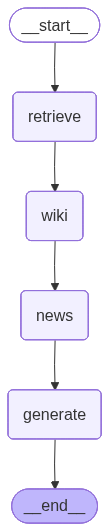

In [88]:
graph

In [91]:
result = graph.invoke({
    "question": "What is Cyber Security meaning in this pdf"
},config=config)

print(result["answer"])

 In the provided context, Cyber Security refers to the practice of protecting digital files, data, networks, and programs from unauthorized access, attacks, or damage. Its objectives are confidentiality, integrity, and availability. It ensures protection against identity theft, fraud, and cyber-attacks. This includes protecting computer software, systems, and networks from threats that can lead to unauthorized information disclosure, theft, or damage to hardware, software, or data, as well as to the disruption or misdirection of the services they provide.


In [92]:
result = graph.invoke({
    "question": "What is the question i asked u earlier"
},config=config)

print(result["answer"])

 Cybersecurity is a broad term used to protect digital systems, networks, and data from unauthorized access, theft, and damage. It includes various measures such as encryption, firewalls, intrusion detection systems, and security awareness training. The goal of cybersecurity is to ensure confidentiality, integrity, authentication, and non-repudiation of information.

Backdoor refers to any secret method of bypassing normal authentication or security controls in a computer system. This can be due to original design flaws or poor configuration. A backdoor can pose a significant risk to the security of a system, as it provides unauthorized access to attackers who have obtained control over the machine.

Network-based Intrusion Detection System (NIDS) is a tool used to monitor network traffic for attacks like Denial of Service (DoS) and send alerts when such attacks are detected. NIDS can help organizations detect and respond to security breaches quickly, reducing the potential damage caus